In [2]:
from pyclustering.cluster.cure import cure
from pyclustering.cluster import cluster_visualizer
from sklearn.mixture import GaussianMixture

from imports import *

artists = pd.read_parquet("tmp/p01_artists.parquet")
tracks = pd.read_parquet("tmp/tracks_with_embeddings.parquet")

X_tsne2 = pd.read_parquet("tmp/X_tsne2.parquet")
X_tsne3 = pd.read_parquet("tmp/X_tsne3.parquet")

X_umap3 = pd.read_parquet("tmp/X_umap3.parquet")
X_umap5 = pd.read_parquet("tmp/X_umap5.parquet")
X_umap8 = pd.read_parquet("tmp/X_umap8.parquet")

pca_audio_cols = pickle.load(open("tmp/pca_audio_cols.pkl", "rb"))
pca_clust_cols = pickle.load(open("tmp/pca_clust_cols.pkl", "rb"))
emb_cols = pickle.load(open("tmp/emb_cols.pkl", "rb"))

## CURE

In [3]:
def cure_test(X, k_min=2, k_max=10):
    X_array = X.to_numpy(dtype='double') if hasattr(X, 'to_numpy') else np.array(X, dtype='double')
    X_list = X_array.tolist()

    for n_clusters in range(k_min, k_max + 1):
        labels = np.full(len(X_array), -1, dtype=int)
        
        cure_instance = cure(X_list, number_cluster=n_clusters, number_represent_points=5, compression=0.5)
        cure_instance.process()
        clusters_indexes = cure_instance.get_clusters()
        
        for cluster_id, indexes in enumerate(clusters_indexes):
            for index in indexes:
                labels[index] = cluster_id
        
        try:
            sil = metrics.silhouette_score(X_array, labels)
            print(f"k={n_clusters} | Silhouette: {sil:.4f}")
        except Exception as e:
            print(f"k={n_clusters} | Silhouette Error: {e}")

        unique_labels, counts = np.unique(labels, return_counts=True)
        valid_mask = (unique_labels != -1) & (counts > 1)
        valid_cluster_ids = unique_labels[valid_mask]

        if len(valid_cluster_ids) < 2:
            print(f"k={n_clusters} | DBCV: Skip (less than 2 valid non-singleton clusters)")
            continue

        mask = np.isin(labels, valid_cluster_ids)
        clean_X = X_array[mask]
        raw_labels = labels[mask]

        label_map = {old_id: new_id for new_id, old_id in enumerate(valid_cluster_ids)}
        clean_labels = np.array([label_map[l] for l in raw_labels])

        try:
            dbcv = hdbscan.validity.validity_index(clean_X, clean_labels.astype(np.int64))
            print(f"k={n_clusters} | DBCV: {dbcv:.4f}")
        except Exception as e:
            print(f"k={n_clusters} | DBCV Error: {e}")
            
    return labels

In [ ]:
labels = cure_test(tracks[pca_clust_cols])

k=2 | Silhouette: 0.3628
k=2 | DBCV: -0.0223
k=3 | Silhouette: 0.3566
k=3 | DBCV: -0.0222
k=4 | Silhouette: 0.3314
k=4 | DBCV: -0.0222
k=5 | Silhouette: 0.3198
k=5 | DBCV: -0.0222
k=6 | Silhouette: 0.3088
k=6 | DBCV: -0.0222
k=7 | Silhouette: 0.2555
k=7 | DBCV: -0.0222
k=8 | Silhouette: 0.2400
k=8 | DBCV: -0.0222
k=9 | Silhouette: 0.2187
k=9 | DBCV: -0.0222
k=10 | Silhouette: 0.2009


In [ ]:
labels = cure_test(tracks[pca_clust_cols], k_min = 5, k_max = 5)
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())

k=5 | Silhouette: 0.3198
k=5 | DBCV: -0.0222
cluster
0    9949
4       2
3       1
1       1
2       1
Name: count, dtype: int64


In [ ]:
labels = cure_test(tracks[pca_clust_cols], k_min = 10, k_max = 10)
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())

k=10 | Silhouette: 0.2009
k=10 | DBCV: -0.0222
cluster
0    9943
9       2
1       2
3       1
7       1
5       1
8       1
4       1
6       1
2       1
Name: count, dtype: int64


In [ ]:
labels = cure_test(tracks[pca_audio_cols])

k=2 | Silhouette: 0.3753
k=2 | DBCV: Skip (less than 2 valid non-singleton clusters)
k=3 | Silhouette: 0.2986
k=3 | DBCV: -0.2347
k=4 | Silhouette: 0.2689
k=4 | DBCV: -0.2347
k=5 | Silhouette: 0.2499
k=5 | DBCV: -0.3237
k=6 | Silhouette: 0.2307
k=6 | DBCV: -0.3237
k=7 | Silhouette: 0.2009
k=7 | DBCV: -0.3237
k=8 | Silhouette: 0.1488
k=8 | DBCV: -0.3237
k=9 | Silhouette: 0.1157
k=9 | DBCV: -0.3237
k=10 | Silhouette: 0.0865
k=10 | DBCV: -0.3236


In [ ]:
labels = cure_test(tracks[pca_audio_cols], k_min = 10, k_max = 10)
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())

k=10 | Silhouette: 0.0865
k=10 | DBCV: -0.3236
cluster
0    9940
5       3
1       3
8       2
4       1
7       1
3       1
2       1
9       1
6       1
Name: count, dtype: int64


A single cluster... this is useless too.

In [ ]:
labels = cure_test(X_umap5)

k=2 | Silhouette: 0.1670
k=2 | DBCV: -0.5342
k=3 | Silhouette: -0.0553
k=3 | DBCV: -0.5947
k=4 | Silhouette: -0.1165
k=4 | DBCV: -0.5941
k=5 | Silhouette: -0.2712
k=5 | DBCV: -0.5939
k=6 | Silhouette: -0.2469
k=6 | DBCV: -0.5867
k=7 | Silhouette: -0.2639
k=7 | DBCV: -0.5766
k=8 | Silhouette: -0.2884
k=8 | DBCV: -0.5764
k=9 | Silhouette: -0.3162
k=9 | DBCV: -0.5761
k=10 | Silhouette: -0.3336
k=10 | DBCV: -0.5761


In [ ]:
labels = cure_test(X_umap5,k_min=2, k_max=2)
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())

k=2 | Silhouette: 0.1670
k=2 | DBCV: -0.5342
cluster
0    9823
1     131
Name: count, dtype: int64


<Axes: xlabel='umap5_1', ylabel='umap5_2'>

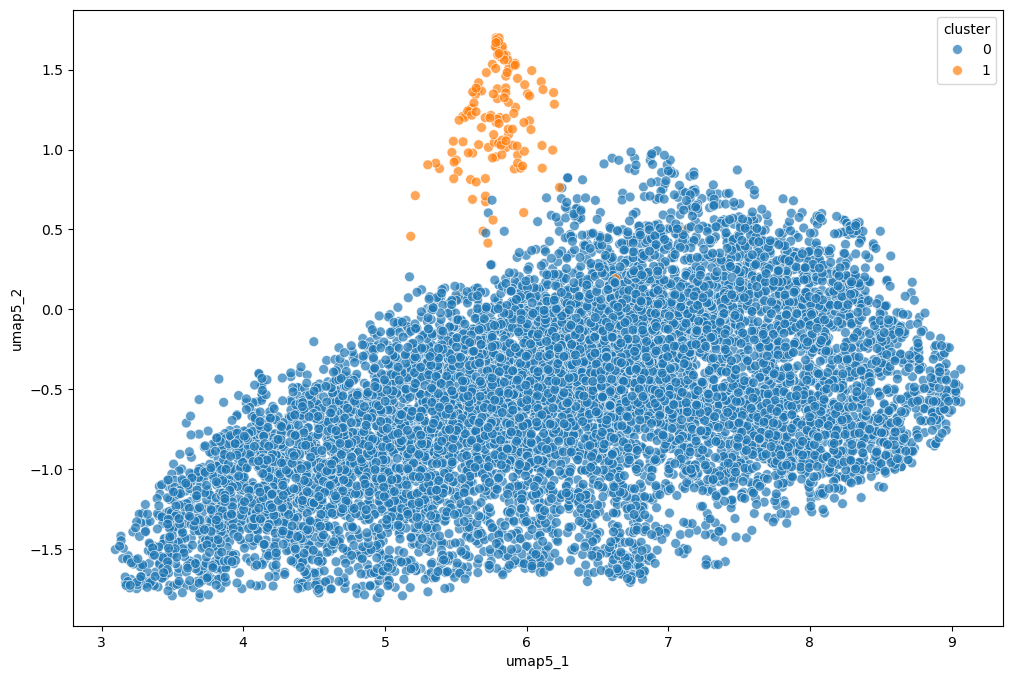

In [ ]:
X = X_umap5
X['cluster'] = labels
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[1],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

## XMEANS

In [ ]:
from pyclustering.cluster.xmeans import xmeans
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
import warnings

np.warnings = warnings

def xmeans_test(X, k_max=15):
    data_list = X.values.tolist()
    
    amount_initial_centers = 2
    initial_centers = kmeans_plusplus_initializer(data_list, amount_initial_centers).initialize()
    
    xmeans_instance = xmeans(data_list, initial_centers, kmax=k_max, ccore=True)
    
    xmeans_instance.process()
    
    clusters = xmeans_instance.get_clusters()
    centers = xmeans_instance.get_centers()
    
    n_clusters = len(clusters)
    
    labels = np.zeros(len(X)) - 1
    for cluster_id, indexes in enumerate(clusters):
        for index in indexes:
            labels[index] = cluster_id
            
    # 6. Metriche
    if n_clusters > 1:
        sil = metrics.silhouette_score(X, labels)
        counts = np.bincount(labels.astype(int))
        
        print(f"Silhouette Score: {sil:.4f}, n_clusters: {n_clusters}")
    else:
        print("Only 1 cluster")

    return labels


Silhouette Score: 0.1579, n_clusters: 2
cluster
0.0    5631
1.0    4323
Name: count, dtype: int64


/tmp/ipykernel_24802/838857042.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = labels


<Axes: xlabel='pc_clust_1', ylabel='pc_clust_2'>

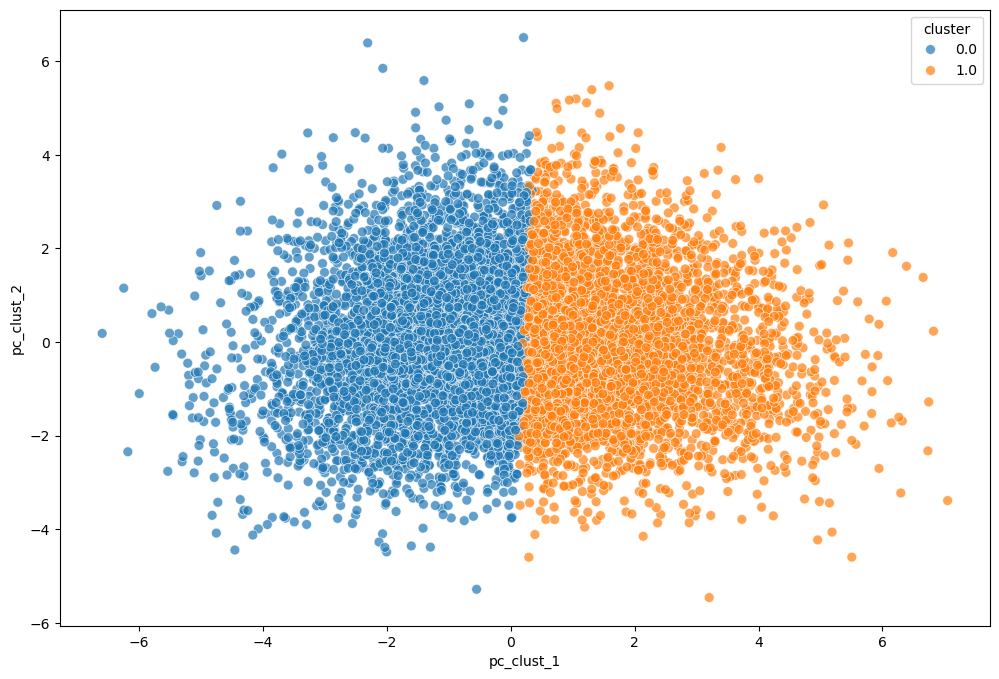

In [ ]:
labels = xmeans_test(tracks[pca_clust_cols])
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())
X = tracks[pca_clust_cols]
X['cluster'] = labels
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[1],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

Silhouette Score: 0.2263, n_clusters: 2
cluster
0.0    5763
1.0    4191
Name: count, dtype: int64


/tmp/ipykernel_24802/690926790.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = labels


<Axes: xlabel='pc_audio_1', ylabel='pc_audio_2'>

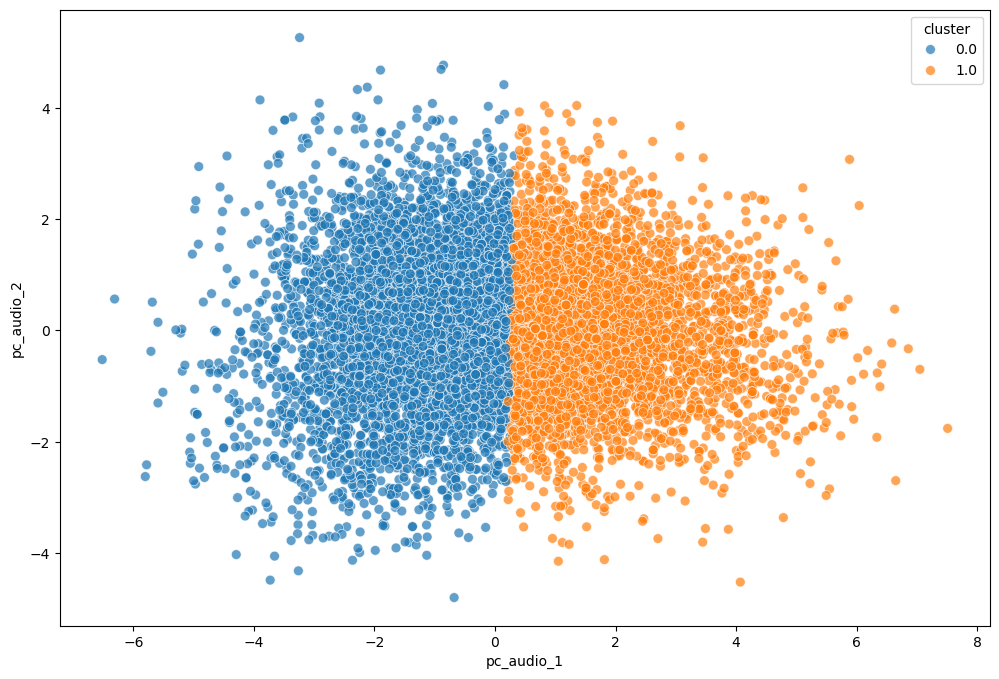

In [ ]:
labels = xmeans_test(tracks[pca_audio_cols])
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())
X = tracks[pca_audio_cols]
X['cluster'] = labels
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[1],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

Silhouette Score: 0.4566, n_clusters: 15
cluster
7.0     1105
9.0     1059
10.0    1017
8.0      890
0.0      834
1.0      806
11.0     631
12.0     629
13.0     575
4.0      566
6.0      542
2.0      447
3.0      375
5.0      285
14.0     193
Name: count, dtype: int64


<Axes: xlabel='umap3_1', ylabel='umap3_2'>

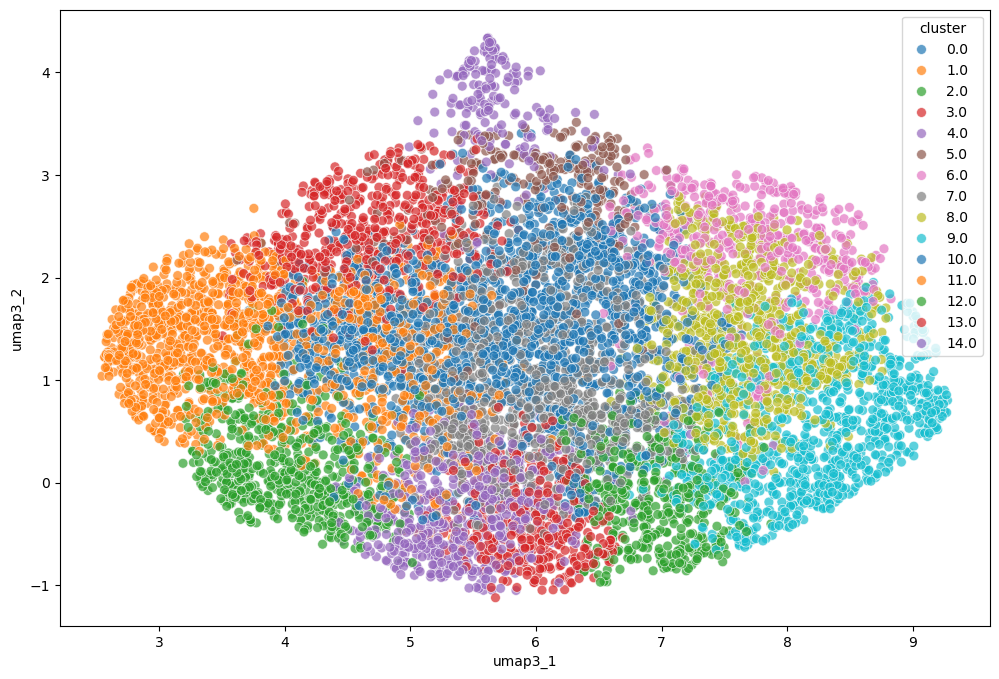

In [ ]:
labels = xmeans_test(X_umap3)
tracks['cluster'] = labels
print(tracks['cluster'].value_counts())
X = X_umap3
X['cluster'] = labels
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=X,
    x=X.columns[0],
    y=X.columns[1],
    hue='cluster',          
    palette='tab10',       
    s=50,                   
    alpha=0.7,              
    legend='full'
)

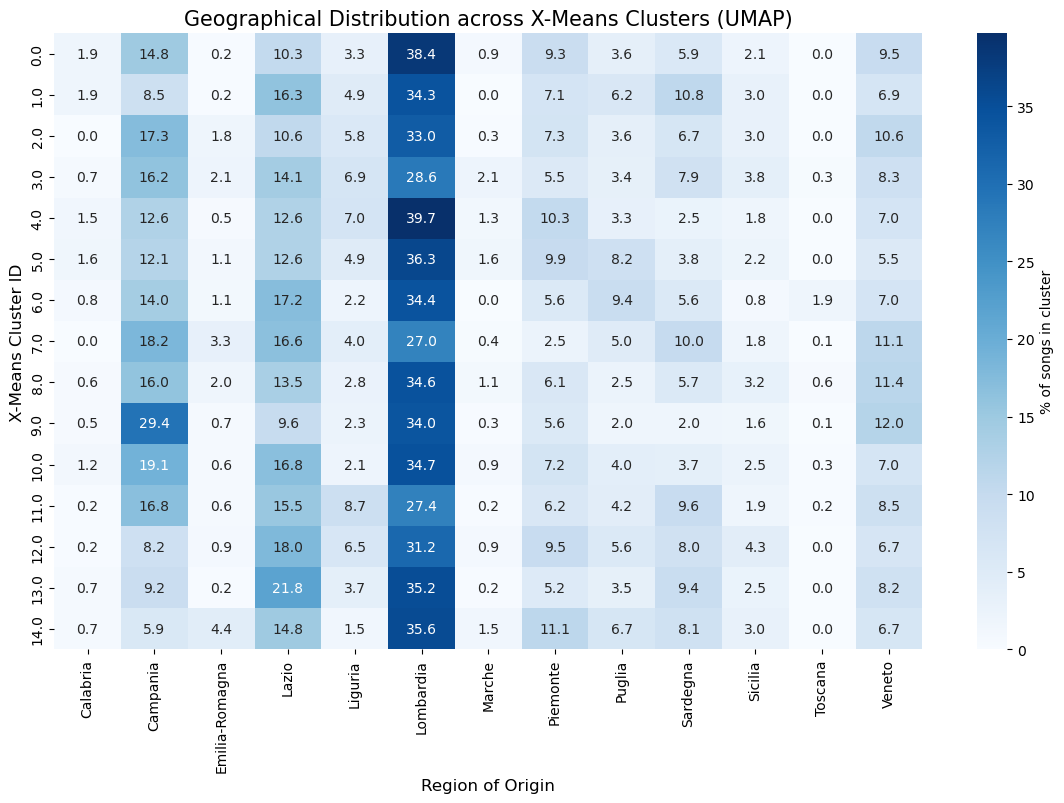

In [ ]:
df_merged = tracks.merge(artists[['id_author', 'province', 'gender']], 
                             left_on='id_artist', 
                             right_on='id_author', 
                             how='left')

df_merged['XMeans_Cluster'] = labels

region_dist = pd.crosstab(df_merged['XMeans_Cluster'], df_merged['region'], normalize='index') * 100

# 4. Visualization: Heatmap of Regions per Cluster
plt.figure(figsize=(14, 8))
sns.heatmap(region_dist, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '% of songs in cluster'})
plt.title('Geographical Distribution across X-Means Clusters (UMAP)', fontsize=15)
plt.xlabel('Region of Origin', fontsize=12)
plt.ylabel('X-Means Cluster ID', fontsize=12)
plt.show()

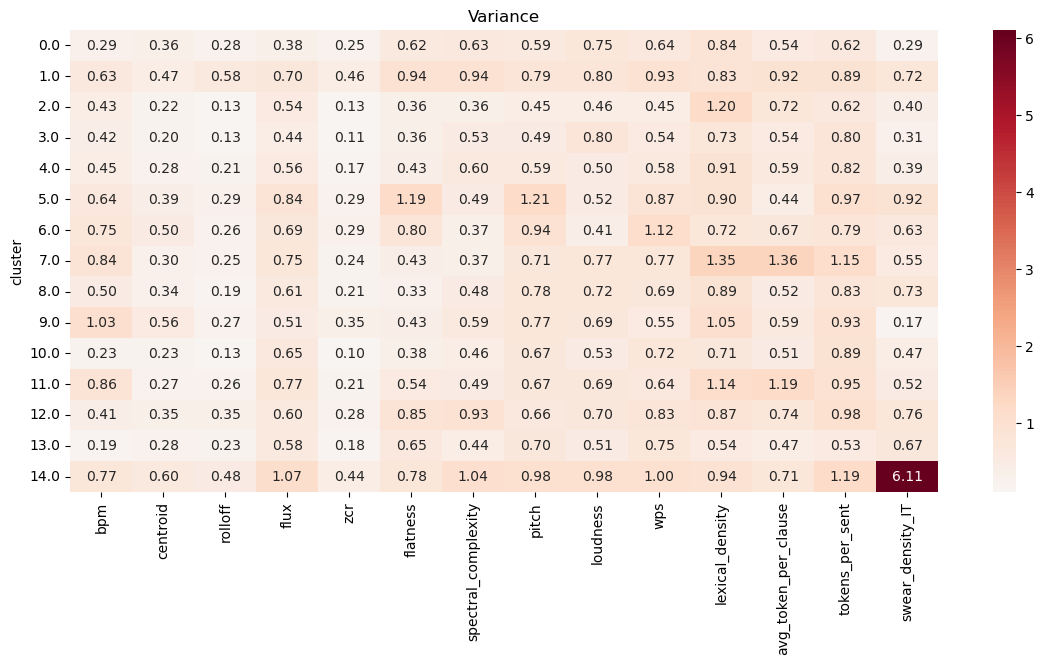

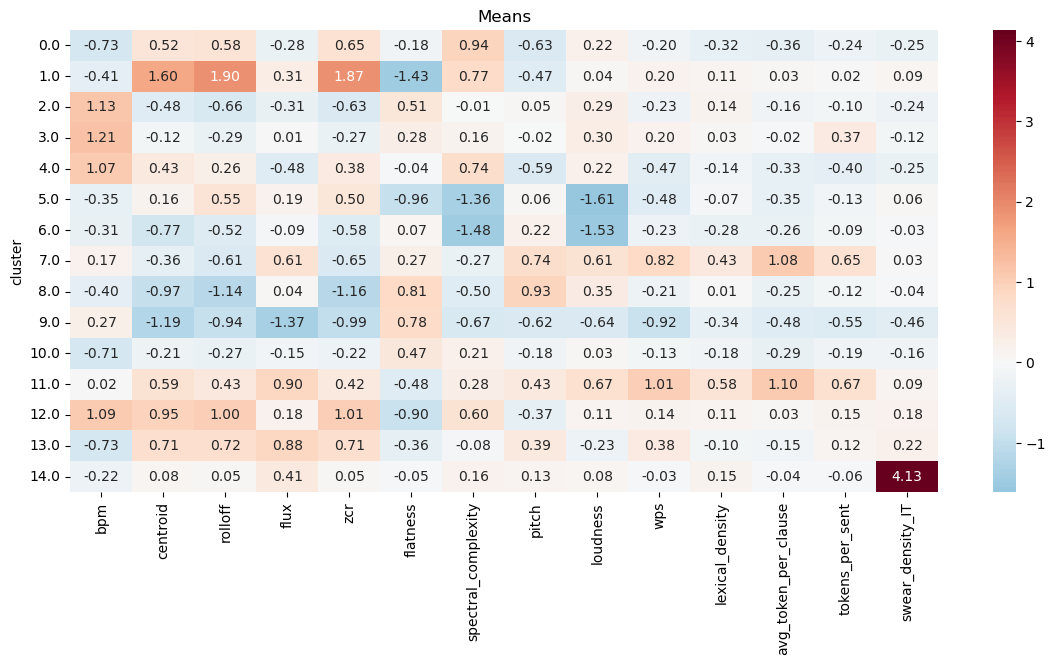

Esempi Cluster 1.0:
             title    year
0     ​polka 2 :-/  2021.0
1            POLKA  2020.0
8    MADE IN ITALY  2023.0
11      COSANOSTRA  2020.0
14       ​life :-(  2021.0
15      RAF SIMONS  2020.0
21      Facciamolo  2019.0
22      Scolapasta  2019.0
28           ceo 2  2025.0
52  esse Type beat  2024.0
name_artist
Mondo Marcio    36
Club Dogo       28
Guè             27
Vacca           27
Gemitaiz        26
Fabri Fibra     25
Nerone          25
Dani Faiv       22
Emis Killa      21
Fedez           20
dtype: int64
Esempi Cluster 11.0:
                  title    year
2          ​britney ;-)  2021.0
6             LOBBY WAY  2020.0
35                0.25X  2025.0
38           TECKTONiiK  2025.0
40               bRAtZz  2025.0
45                  X&V  2025.0
67               TONICA  2019.0
101      Rolling Papers  2025.0
114       a me mi piace  2025.0
180  ​blun7 a swishland  2019.0
name_artist
Guè           34
Nerone        31
Dani Faiv     31
Vacca         22
Gemitaiz      2

In [ ]:
scaler = StandardScaler()
tracks_scaled = pd.DataFrame(
    scaler.fit_transform(tracks[clust_cols]), 
    columns=clust_cols, 
    index=tracks.index
)
tracks_scaled['cluster'] = tracks['cluster']

cluster_variance_std = tracks_scaled.groupby('cluster')[clust_cols].var()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_variance_std, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title('Variance')
plt.show()

cluster_means = tracks_scaled.groupby('cluster')[clust_cols].mean()
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title('Means')
plt.show()

for c in tracks['cluster'].unique():
    print(f"Examples for cluster {c}:")
    print(tracks[tracks['cluster'] == c][['title', 'year']].head(10)) 
    print(tracks[tracks['cluster'] == c].groupby('name_artist').size().sort_values(ascending=False).head(10))

print("::::::::::::::::::::::::::::")
print(tracks.groupby('cluster')['year'].mean())

print("::::::::::::::::::::::::::::")

## Embeddings

Let's try with topics

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import torch
import re

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('tmp/BERT-model/paraphrase-multilingual-MiniLM-L12-v2', device=device)

labels_config = {
    "Criminalità": "ferro pistola sparare cella secondino avvocato guardie infame spaccio piazza panette bilancino",
    "Old School": "microfono palco suona cassa rullante vinile dj mc rispetto scena rappresento vero falso",
    "Sesso & Corpo": "sesso letto nuda corpo perversione spogliati godere pelle lenzuola scopare",
    "Disagio Mentale": "depressione ansia panico farmaci psicologo suicidio mostri testa buio malessere paranoie",
    "Successo & Ego": "soldi lusso rolex contanti classifica primo migliore king vincere invidia fatturare",
    "Conscious": "potere verità bugie schiavi catene mente sveglia diritti guerra pace mondo tv giornali",
    "Party & Club": "baila muovere cassa shot vodka gin tonic sbocciare locale privé mattina ubriaco",
    "Chill & Weed": "fumo cartine accendino nuvole occhi rossi divano volare tranquillo joint lean",
    "Famiglia": "mamma pa' casa tavola cresciuto bambini quartiere ricordo"
}

labels_names = list(labels_config.keys())
labels_text = list(labels_config.values())

label_embeddings = model.encode(labels_text)

similarity_matrix = cosine_similarity(tracks[emb_cols], label_embeddings)

best_topic_indices = np.argmax(similarity_matrix, axis=1)
tracks['predicted_topic'] = [labels_names[i] for i in best_topic_indices]
tracks['predicted_topic_confidence'] = np.max(similarity_matrix, axis=1)


print(tracks['predicted_topic'].value_counts())

results = []

for topic in labels_names:
    subset_embeddings = tracks[tracks['predicted_topic'] == topic][emb_cols].values
    
    if len(subset_embeddings) < 2:
        continue
        
    topic_centroid = np.mean(subset_embeddings, axis=0).reshape(1, -1)
    similarities = cosine_similarity(subset_embeddings, topic_centroid)
    
    results.append({
        'Topic': topic,
        'Cohesion (avg Sim)': np.mean(similarities),
        'Variance (Std Dev)': np.std(similarities),
        'N_Songs': len(subset_embeddings)
    })

df_cohesion = pd.DataFrame(results).sort_values(by='Cohesion (avg Sim)', ascending=False)
print(df_cohesion)

predicted_topic
Criminalità        2364
Famiglia           2086
Old School         1726
Chill & Weed       1042
Conscious          1011
Sesso & Corpo       517
Successo & Ego      407
Party & Club        401
Disagio Mentale     400
Name: count, dtype: int64
             Topic  Cohesion (avg Sim)  Variance (Std Dev)  N_Canzoni
0      Criminalità            0.723360            0.087931       2364
3  Disagio Mentale            0.721203            0.080263        400
1       Old School            0.719994            0.077714       1726
7     Chill & Weed            0.713892            0.079788       1042
6     Party & Club            0.708613            0.083212        401
8         Famiglia            0.701688            0.085357       2086
2    Sesso & Corpo            0.694437            0.088395        517
5        Conscious            0.693236            0.085123       1011
4   Successo & Ego            0.681483            0.079938        407


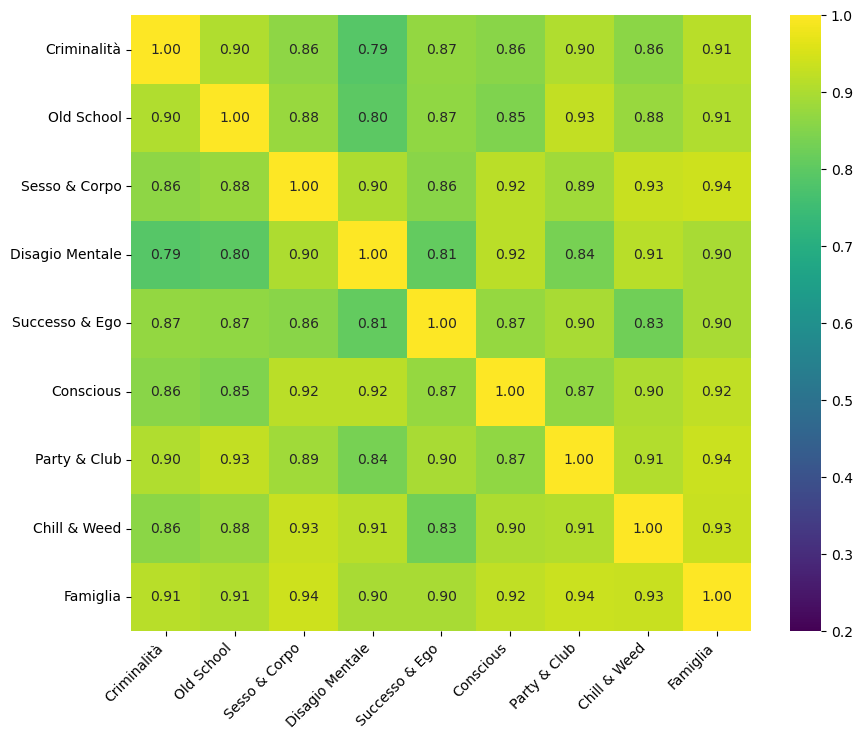

In [ ]:
topic_centroids = []
valid_topics = []

for topic in labels_names:
    subset = tracks[tracks['predicted_topic'] == topic]
    if len(subset) < 2: continue
    
    centroid = np.mean(subset[emb_cols].values, axis=0)
    topic_centroids.append(centroid)
    valid_topics.append(topic)

matrix_centroids = np.array(topic_centroids)
sim_matrix = cosine_similarity(matrix_centroids)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix, 
    annot=True,              
    fmt=".2f",               
    xticklabels=valid_topics,
    yticklabels=valid_topics,
    cmap="viridis",          
    vmin=0.2, vmax=1.0       
)

plt.xticks(rotation=45, ha='right')
plt.show()

The average similarity of the whole dataset is 0.67. Inside clusters, the average similarity is slightly higher.